In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
OUTPUT_DIR = Path("../reports")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("08 — SKEWNESS ANALİZİ: min_seg_size_forward Removal")
print("=" * 60)

08 — SKEWNESS ANALİZİ: min_seg_size_forward Removal


In [2]:
FEATURED_PATH  = "../data/csv/featured_dataset.csv"
FEATURES_TXT   = "../data/csv/selected_features.txt"
LABEL_MAP_PATH = "../data/csv/label_mapping.csv"

with open(FEATURES_TXT) as f:
    FEATURE_COLS = [line.strip() for line in f if line.strip()]

label_mapping = pd.read_csv(LABEL_MAP_PATH)
INT_TO_LABEL  = dict(zip(label_mapping["label_int"], label_mapping["label_string"]))

df = pd.read_csv(FEATURED_PATH, low_memory=False)
print(f"Dataset: {df.shape[0]:,} satır, {len(FEATURE_COLS)} feature")

Dataset: 495,855 satır, 47 feature


In [3]:
TARGET_FEATURE = "min_seg_size_forward"

# Feature listesinde var mı kontrol et
target_in_list = [f for f in FEATURE_COLS if f == TARGET_FEATURE]

if target_in_list:
    skew_val = df[TARGET_FEATURE].skew()
    print(f"'{TARGET_FEATURE}' feature listesinde BULUNDU")
    print(f"  Skewness değeri: {skew_val:.2f}")
    print(f"  Bu değer çok yüksek çarpıklığa işaret ediyor (tipik eşik: |10|)")
    print(f"  Hocanın tespiti: ~-682 → yanıltıcı/outlier etkisi")
else:
    print(f"[UYARI] '{TARGET_FEATURE}' feature listesinde bulunamadı.")
    print("  03_feature_engineering'de korelasyon filtresi ile çıkarılmış olabilir.")
    print("  Bu durumda bu notebook'u çalıştırmaya gerek yok.")

'min_seg_size_forward' feature listesinde BULUNDU
  Skewness değeri: -681.74
  Bu değer çok yüksek çarpıklığa işaret ediyor (tipik eşik: |10|)
  Hocanın tespiti: ~-682 → yanıltıcı/outlier etkisi


In [4]:
def train_evaluate_rf(X, y, experiment_name, int_to_label=None):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )
    model = RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=2
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "experiment":   experiment_name,
        "n_features":   X.shape[1],
        "accuracy":     accuracy_score(y_test, y_pred),
        "precision_w":  precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_w":     recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted":  f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro":     f1_score(y_test, y_pred, average="macro", zero_division=0),
    }
    return model, metrics, y_test, y_pred


def plot_confusion_matrix(y_true, y_pred, title, save_path, int_to_label=None):
    labels = sorted(set(y_true) | set(y_pred))
    if int_to_label:
        display_labels = [int_to_label.get(l, str(l)) for l in labels]
    else:
        display_labels = [str(l) for l in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, data, fmt, subtitle in [
        (axes[0], cm,      ",d",  "Ham Sayılar"),
        (axes[1], cm_norm, ".2f", "Normalize (Recall bazında)")
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=display_labels, yticklabels=display_labels,
                    ax=ax, annot_kws={"size": 7})
        ax.set_xlabel("Tahmin Edilen")
        ax.set_ylabel("Gerçek")
        ax.set_title(subtitle)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Kaydedildi: {save_path}")

DENEY 1: min_seg_size_forward İÇERİDE (leakage çıkarılmış)
  Feature sayısı: 46
  Accuracy       : 0.9962
  F1 Weighted    : 0.9961
  F1 Macro       : 0.9108


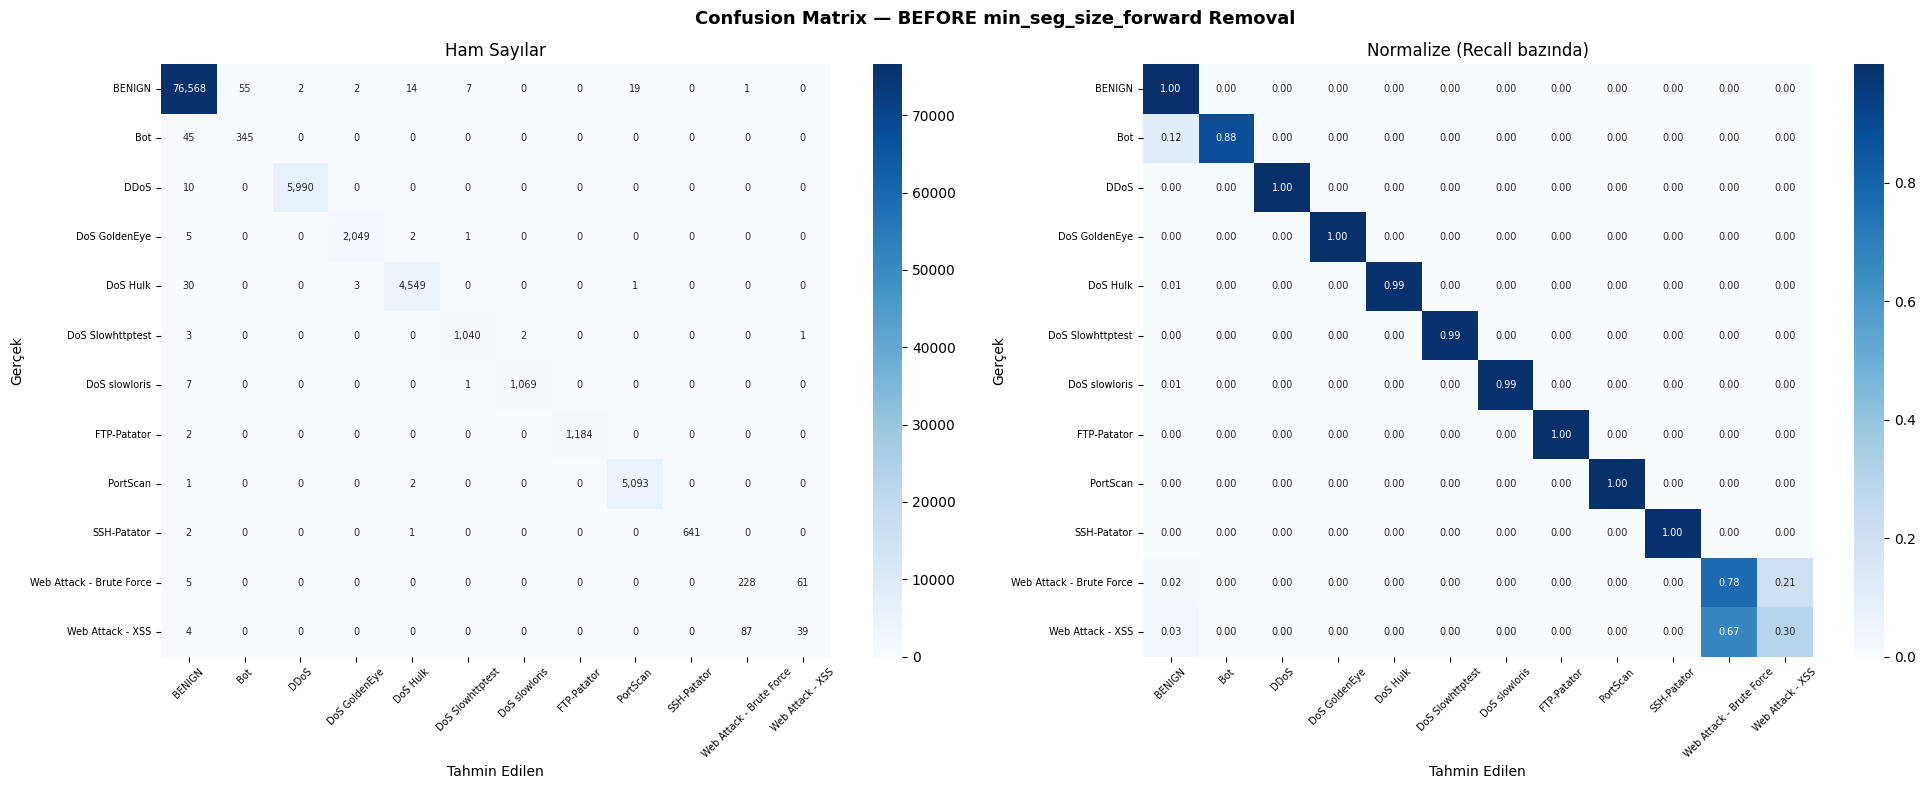

✓ Kaydedildi: ../reports/confusion_skew_before.png


In [5]:
import re

# Önce leakage feature'ları çıkar (07'deki ile aynı)
LEAKAGE_PATTERNS = [
    r"source.?address", r"destination.?address",
    r"src.?ip", r"dst.?ip",
    r"source.?ip", r"destination.?ip",
    r"flow.?id", r"timestamp",
]
PORT_PATTERNS = [r"^destination.?port$"]

def find_matching_columns(columns, patterns):
    found = []
    for col in columns:
        col_norm = col.lower().strip().replace(" ", "_")
        for pat in patterns:
            if re.search(pat, col_norm):
                found.append(col)
                break
    return sorted(set(found))

leakage_cols = find_matching_columns(FEATURE_COLS, LEAKAGE_PATTERNS)
port_cols    = find_matching_columns(FEATURE_COLS, PORT_PATTERNS)
all_leakage  = sorted(set(leakage_cols + port_cols))

# Leakage çıkarılmış feature listesi (ama min_seg_size_forward hâlâ içeride)
features_no_leak = [f for f in FEATURE_COLS if f not in all_leakage]

print("=" * 60)
print("DENEY 1: min_seg_size_forward İÇERİDE (leakage çıkarılmış)")
print("=" * 60)
print(f"  Feature sayısı: {len(features_no_leak)}")

y_mc = df["label_multiclass"].values
X_before = df[features_no_leak].values

_, metrics_before, yt_b, yp_b = train_evaluate_rf(
    X_before, y_mc, "BEFORE_min_seg_removal", INT_TO_LABEL
)

print(f"  Accuracy       : {metrics_before['accuracy']:.4f}")
print(f"  F1 Weighted    : {metrics_before['f1_weighted']:.4f}")
print(f"  F1 Macro       : {metrics_before['f1_macro']:.4f}")

plot_confusion_matrix(
    yt_b, yp_b,
    "Confusion Matrix — BEFORE min_seg_size_forward Removal",
    OUTPUT_DIR / "confusion_skew_before.png",
    INT_TO_LABEL
)

DENEY 2: min_seg_size_forward ÇIKARILDI
  'min_seg_size_forward' çıkarıldı.
  Kalan feature sayısı: 45
  Accuracy       : 0.9960
  F1 Weighted    : 0.9959
  F1 Macro       : 0.9068


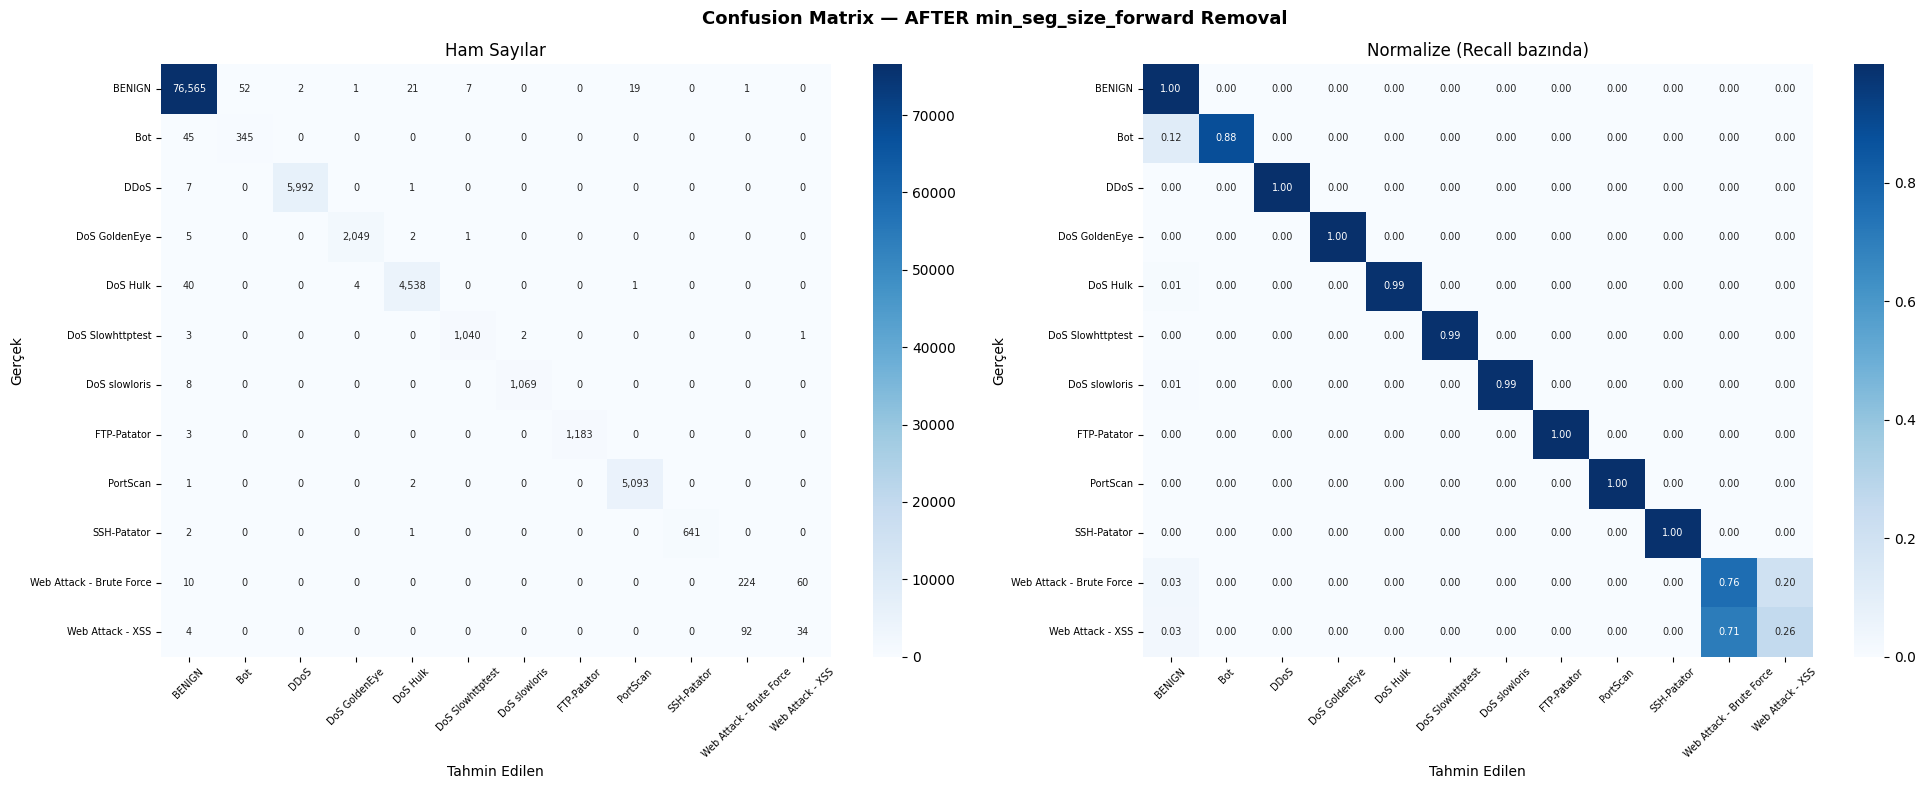

✓ Kaydedildi: ../reports/confusion_skew_after.png


In [6]:
print("=" * 60)
print("DENEY 2: min_seg_size_forward ÇIKARILDI")
print("=" * 60)

if TARGET_FEATURE in features_no_leak:
    features_no_skew = [f for f in features_no_leak if f != TARGET_FEATURE]
    print(f"  '{TARGET_FEATURE}' çıkarıldı.")
else:
    features_no_skew = features_no_leak.copy()
    print(f"  '{TARGET_FEATURE}' zaten listede yok, aynı listeyle devam ediliyor.")

print(f"  Kalan feature sayısı: {len(features_no_skew)}")

X_after = df[features_no_skew].values

_, metrics_after, yt_a, yp_a = train_evaluate_rf(
    X_after, y_mc, "AFTER_min_seg_removal", INT_TO_LABEL
)

print(f"  Accuracy       : {metrics_after['accuracy']:.4f}")
print(f"  F1 Weighted    : {metrics_after['f1_weighted']:.4f}")
print(f"  F1 Macro       : {metrics_after['f1_macro']:.4f}")

plot_confusion_matrix(
    yt_a, yp_a,
    "Confusion Matrix — AFTER min_seg_size_forward Removal",
    OUTPUT_DIR / "confusion_skew_after.png",
    INT_TO_LABEL
)

In [7]:
print("=" * 60)
print("SKEWNESS KARŞILAŞTIRMA TABLOSU")
print("=" * 60)

comp_skew = pd.DataFrame([metrics_before, metrics_after])
comp_skew["delta_accuracy"]    = comp_skew["accuracy"]    - metrics_before["accuracy"]
comp_skew["delta_f1_weighted"] = comp_skew["f1_weighted"] - metrics_before["f1_weighted"]
comp_skew["delta_f1_macro"]    = comp_skew["f1_macro"]    - metrics_before["f1_macro"]

display_cols = ["experiment", "n_features", "accuracy", "precision_w", "recall_w",
                "f1_weighted", "f1_macro", "delta_accuracy", "delta_f1_weighted", "delta_f1_macro"]

print(comp_skew[display_cols].round(4).to_string(index=False))

comp_skew.to_csv(OUTPUT_DIR / "skewness_comparison.csv", index=False)
print(f"\n✓ Kaydedildi: {OUTPUT_DIR / 'skewness_comparison.csv'}")

SKEWNESS KARŞILAŞTIRMA TABLOSU
            experiment  n_features  accuracy  precision_w  recall_w  f1_weighted  f1_macro  delta_accuracy  delta_f1_weighted  delta_f1_macro
BEFORE_min_seg_removal          46    0.9962       0.9961    0.9962       0.9961    0.9108          0.0000             0.0000           0.000
 AFTER_min_seg_removal          45    0.9960       0.9958    0.9960       0.9959    0.9068         -0.0002            -0.0002          -0.004

✓ Kaydedildi: ../reports/skewness_comparison.csv
